In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv("/kaggle/input/datasets/pheobebuffe/numero-esim-purchases/Copy of Numero eSIM_purchases (2024 - 2025).csv")

df['purchase_date'] = pd.to_datetime(df['purchase_date'])
df['register_date']  = pd.to_datetime(df['register_date'])
df = df.rename(columns={'prodcut': 'product'})
df['price'] = df['price'].fillna(df['price'].mean())

# Sets 'today' as the most recent purchase date in the dataset (since it's historical data) to use as a reference point for recency and reactivation calculations.
today = df['purchase_date'].max()

# The company requested we group the 8 products into 3 super classes, and perform a seperate clustering algorithm on each super class.
product_group_map = {
    'Phone Number':       'Virtual Number',
    'Local Calling Plan': 'Virtual Number',
    'EU Bundle':          'Virtual Number',
    'Full eSIM':          'Data eSIM',
    'Local eSIM':         'Data eSIM',
    'Data eSIM':          'Data eSIM',
    'Calling Offers':     'Calls',
    'Recharge':           'Calls',
}

df['product_group'] = df['product'].map(product_group_map)

print(df.shape)
df.head()

(826859, 14)


,id_client,purchase_date,product,product_type,details,renewal_status,price,User Country,User phone number,register_date,platform,email,language,product_group
0,15736044,2024-01-01,Data eSIM,Germany,1 GB,New,2.5,Germany,4915219617737,2024-01-01,iOS,NaN,english,Data eSIM
1,15736461,2024-01-01,Data eSIM,Spain,1 GB,New,3.0,Tunisia,21622062281,2024-01-01,iOS,NaN,french,Data eSIM
2,15736510,2024-01-01,Data eSIM,China,1 GB,New,5.0,Colombia,573155801176,2024-01-01,Android,NaN,spanish,Data eSIM
3,15736510,2024-01-01,Data eSIM,Indonesia,1 GB,New,5.0,Colombia,573155801176,2024-01-01,Android,NaN,spanish,Data eSIM
4,15737233,2024-01-01,Data eSIM,Australia,1 GB,New,4.0,Egypt,201018518052,2024-01-01,Android,NaN,arabic,Data eSIM


In [3]:
def build_client_features(df_group, today):
    g = df_group.copy()

    # Groups data by client ID and computes customer-level metrics like recency, age, purchase history, 
    # spending totals, averages, variability, and product diversity, then resets the index.
    base = g.groupby('id_client').agg(
        recency          = ('purchase_date', lambda x: (today - x.max()).days),
        customer_age     = ('register_date', lambda x: (today - x.min()).days),
        first_purchase   = ('purchase_date', 'min'),
        last_purchase    = ('purchase_date', 'max'),
        total_purchases  = ('price', 'count'),
        total_spent      = ('price', 'sum'),
        avg_order_value  = ('price', 'mean'),
        std_order_value  = ('price', 'std'),
        unique_products  = ('product',  'nunique'),
    ).reset_index()

    # Replaces NaN std (from single purchases) with 0, then calculates purchase velocity as 
    # purchases per month over the customer’s active period (avoiding division by zero)
    base['std_order_value'] = base['std_order_value'].fillna(0)

    active_days = (base['last_purchase'] - base['first_purchase']).dt.days
    base['purchase_velocity'] = (
        base['total_purchases'] / (active_days.clip(lower=1) / 30)
    )

    # Computes each client's average days between purchases and merges it into the base table, 
    # filling missing values (single purchase cases) with their total active period
    gaps = (g.sort_values(['id_client', 'purchase_date'])
             .groupby('id_client')['purchase_date']
             .apply(lambda x: x.diff().dt.days.mean()))
    base = base.merge(gaps.rename('avg_gap_days').reset_index(), on='id_client', how='left')
    base['avg_gap_days'] = base['avg_gap_days'].fillna(active_days)

    # Calculates each client's total spend per product and converts it into spend shares, 
    # merges these features into the base table, removes raw date columns, and returns the final dataset
    prod_spend = (g.groupby(['id_client', 'product'])['price']
                   .sum().unstack(fill_value=0).reset_index())
    prod_spend.columns = ['id_client'] + [
        f'spend_{c.lower().replace(" ", "_")}' for c in prod_spend.columns[1:]
    ]
    total = prod_spend.drop(columns='id_client').sum(axis=1).replace(0, np.nan)
    for c in prod_spend.columns[1:]:
        prod_spend[c.replace('spend_', 'share_')] = prod_spend[c] / total

    base = base.merge(prod_spend, on='id_client', how='left')
    base = base.drop(columns=['first_purchase', 'last_purchase'])
    return base

In [4]:
# PREP 
# Matches cluster-reactivation-pipeline exactly:
# StandardScaler → PCA(90% variance) → KMeans on PCA space

def prepare_features(features_df):
    feature_cols = [c for c in features_df.columns if c != 'id_client']
    X = features_df[feature_cols].fillna(0)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    pca = PCA(n_components=0.90, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    print(f"  PCA: {pca.n_components_} components → {pca.explained_variance_ratio_.sum():.1%} variance explained")
    return X_pca, scaler, pca


In [5]:
# ELBOW + SILHOUETTE SWEEP
def sweep_k(X_pca, k_range=range(2, 9), sample_size=8000, random_state=42):
    n = X_pca.shape[0]
    idx = np.random.RandomState(random_state).choice(n, min(sample_size, n), replace=False)
    X_sample = X_pca[idx]

    inertias, sil_scores, sil_per_k = [], [], {}

    print(f"\n{'k':>3} | {'Inertia':>12} | {'Silhouette':>10} | {'Avg cluster sizes'}")
    print("─" * 65)

    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init='auto', max_iter=500)
        km.fit(X_pca)
        labels_sample = km.predict(X_sample)

        inertia = km.inertia_
        sil_avg = silhouette_score(X_sample, labels_sample)
        sil_vals = silhouette_samples(X_sample, labels_sample)

        full_labels = km.labels_
        sizes = pd.Series(full_labels).value_counts().sort_index().tolist()
        size_str = "  ".join([f"C{i}:{s:,}" for i, s in enumerate(sizes)])

        inertias.append(inertia)
        sil_scores.append(sil_avg)
        sil_per_k[k] = (sil_vals, labels_sample)

        print(f"{k:>3} | {inertia:>12,.0f} | {sil_avg:>10.4f} | {size_str}")

    return inertias, sil_scores, sil_per_k, list(k_range)


In [6]:
# PLOTS

def plot_diagnostics(k_list, inertias, sil_scores, sil_per_k, chosen_k, title=""):
    fig = plt.figure(figsize=(16, 6))
    fig.suptitle(f"K-Means Validation — {title}  (chosen k={chosen_k})",
                 fontsize=14, fontweight='bold', y=1.01)

    # Elbow
    ax1 = fig.add_subplot(1, 3, 1)
    ax1.plot(k_list, inertias, 'o-', color='steelblue', linewidth=2, markersize=7)
    ax1.axvline(chosen_k, color='red', linestyle='--', alpha=0.8, label=f'Chosen k={chosen_k}')
    ax1.set_title("Elbow — Inertia", fontweight='bold')
    ax1.set_xlabel("k"); ax1.set_ylabel("Inertia")
    ax1.legend(); ax1.grid(alpha=0.3)

    # Silhouette bar
    ax2 = fig.add_subplot(1, 3, 2)
    colors = ['red' if k == chosen_k else 'steelblue' for k in k_list]
    bars = ax2.bar(k_list, sil_scores, color=colors, alpha=0.85, edgecolor='white')
    ax2.set_title("Silhouette Score per k", fontweight='bold')
    ax2.set_xlabel("k"); ax2.set_ylabel("Silhouette")
    ax2.set_ylim(0, max(sil_scores) * 1.2)
    for bar, s in zip(bars, sil_scores):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{s:.3f}', ha='center', va='bottom', fontsize=9)
    ax2.grid(alpha=0.3, axis='y')

    # Silhouette plot for chosen k
    ax3 = fig.add_subplot(1, 3, 3)
    sil_vals, labels = sil_per_k[chosen_k]
    unique_labels = np.unique(labels)
    cmap = plt.colormaps.get_cmap('tab10').resampled(len(unique_labels))
    y_lower = 10
    for i, label in enumerate(unique_labels):
        vals = np.sort(sil_vals[labels == label])
        size = vals.shape[0]
        y_upper = y_lower + size
        ax3.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                          facecolor=cmap(i), alpha=0.8)
        ax3.text(-0.02, y_lower + size / 2, f'C{label}', ha='right', va='center', fontsize=9)
        y_lower = y_upper + 10
    ax3.axvline(np.mean(sil_vals), color='red', linestyle='--', linewidth=1.5, label='Avg')
    ax3.set_title(f"Silhouette Plot — chosen k={chosen_k}", fontweight='bold')
    ax3.set_xlabel("Silhouette coefficient"); ax3.set_ylabel("Clients")
    ax3.legend(); ax3.grid(alpha=0.2)

    plt.tight_layout()
    plt.savefig(f"validation_{title.replace(' ', '_')}.png", dpi=150, bbox_inches='tight')
    plt.show()


In [7]:
# INTERPRET CLUSTERS

def interpret_clusters(features_df, labels):
    key_metrics = [
        'recency', 'customer_age', 'total_purchases', 'total_spent',
        'avg_order_value', 'unique_products', 'purchase_velocity', 'avg_gap_days',
    ]
    df_result = features_df.copy()
    df_result['cluster'] = labels

    cluster_profiles = df_result.groupby('cluster')[key_metrics].mean()

    norm = (cluster_profiles - cluster_profiles.min()) / \
           (cluster_profiles.max() - cluster_profiles.min() + 1e-9)

    print("\n" + "═" * 60)
    print("CLUSTER PROFILES (raw means)")
    print("═" * 60)
    print(cluster_profiles.round(2).to_string())

    fig, ax = plt.subplots(figsize=(max(10, len(key_metrics) * 0.9), 4))
    im = ax.imshow(norm.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
    ax.set_xticks(range(len(key_metrics)))
    ax.set_xticklabels(key_metrics, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(len(norm.index)))
    ax.set_yticklabels([f'Cluster {i}' for i in norm.index], fontsize=10)
    plt.colorbar(im, ax=ax, label='Relative intensity (0=low, 1=high)')
    ax.set_title("Cluster Behavioral Heatmap", fontweight='bold', fontsize=12)
    for i in range(norm.shape[0]):
        for j in range(norm.shape[1]):
            ax.text(j, i, f'{cluster_profiles.values[i, j]:.1f}',
                    ha='center', va='center', fontsize=7.5,
                    color='black' if 0.2 < norm.values[i, j] < 0.8 else 'white')
    plt.tight_layout()
    plt.show()

    size_df = pd.Series(labels).value_counts().sort_index().rename_axis('cluster').reset_index(name='count')
    size_df['pct'] = (size_df['count'] / size_df['count'].sum() * 100).round(1)
    print("\nCluster sizes:")
    print(size_df.to_string(index=False))

    return df_result, cluster_profiles


In [8]:
# PCA SCATTER

def plot_pca_scatter(X_pca, labels, chosen_k, title=""):
    fig, ax = plt.subplots(figsize=(9, 6))
    cmap = plt.colormaps.get_cmap('tab10').resampled(chosen_k)
    for k in range(chosen_k):
        mask = labels == k
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=[cmap(k)], alpha=0.4, s=10, label=f'Cluster {k}')
    ax.set_title(f"PCA Scatter — {title} (k={chosen_k})", fontweight='bold')
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.legend(markerscale=3); ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


In [9]:
def run_group(clients_df, group_name):
    print(f"\n{'═'*65}")
    print(f"  GROUP: {group_name}")
    print(f"{'═'*65}")

    X_pca, scaler, pca = prepare_features(clients_df)

    inertias, sil_scores, sil_per_k, k_list = sweep_k(X_pca, k_range=range(2, 9))

    target_range = [k for k in k_list if 2 <= k <= 5]
    best_in_range = target_range[np.argmax([sil_scores[k_list.index(k)] for k in target_range])]
    global_best   = k_list[np.argmax(sil_scores)]
    recommended_k = best_in_range
    print(f"\n Recommended k = {recommended_k}  (global best silhouette = k={global_best})")

    plot_diagnostics(k_list, inertias, sil_scores, sil_per_k, recommended_k, title=group_name)

    final_km = KMeans(n_clusters=recommended_k, random_state=42, n_init=15, max_iter=500)
    labels = final_km.fit_predict(X_pca)

    labeled_df, profiles = interpret_clusters(clients_df, labels)

    plot_pca_scatter(X_pca, labels, recommended_k, title=group_name)

    return labeled_df, profiles, final_km


In [10]:
df_calls = df[df['product_group'] == 'Calls'].copy()
calls_clients = build_client_features(df_calls, today)
print(f"Calls: {calls_clients.shape[0]:,} unique clients, {calls_clients.shape[1]} features")

Calls: 57,197 unique clients, 14 features


In [11]:
df_esim = df[df['product_group'] == 'Data eSIM'].copy()
esim_clients = build_client_features(df_esim, today)
print(f"eSIM: {esim_clients.shape[0]:,} unique clients, {esim_clients.shape[1]} features")

eSIM: 73,125 unique clients, 16 features


In [12]:
df_virtual = df[df['product_group'] == 'Virtual Number'].copy()
virtual_clients = build_client_features(df_virtual, today)
print(f"Virtual: {virtual_clients.shape[0]:,} unique clients, {virtual_clients.shape[1]} features")

Virtual: 204,821 unique clients, 16 features



═════════════════════════════════════════════════════════════════
  GROUP: Calls
═════════════════════════════════════════════════════════════════
  PCA: 8 components → 91.6% variance explained

  k |      Inertia | Silhouette | Avg cluster sizes
─────────────────────────────────────────────────────────────────
  2 |      548,372 |     0.4328 | C0:12,760  C1:44,437
  3 |      467,061 |     0.4402 | C0:12,821  C1:44,273  C2:103
  4 |      391,401 |     0.4544 | C0:11,400  C1:38,468  C2:80  C3:7,249
  5 |      351,036 |     0.3183 | C0:11,324  C1:20,576  C2:80  C3:6,461  C4:18,756
  6 |      341,908 |     0.2392 | C0:11,286  C1:10,826  C2:80  C3:6,321  C4:15,420  C5:13,264
  7 |      298,210 |     0.2827 | C0:7,502  C1:11,650  C2:78  C3:5,072  C4:14,896  C5:12,833  C6:5,166
  8 |      254,648 |     0.3172 | C0:7,476  C1:12,749  C2:73  C3:11,585  C4:5,384  C5:5,177  C6:13,631  C7:1,122

 Recommended k = 4  (global best silhouette = k=4)


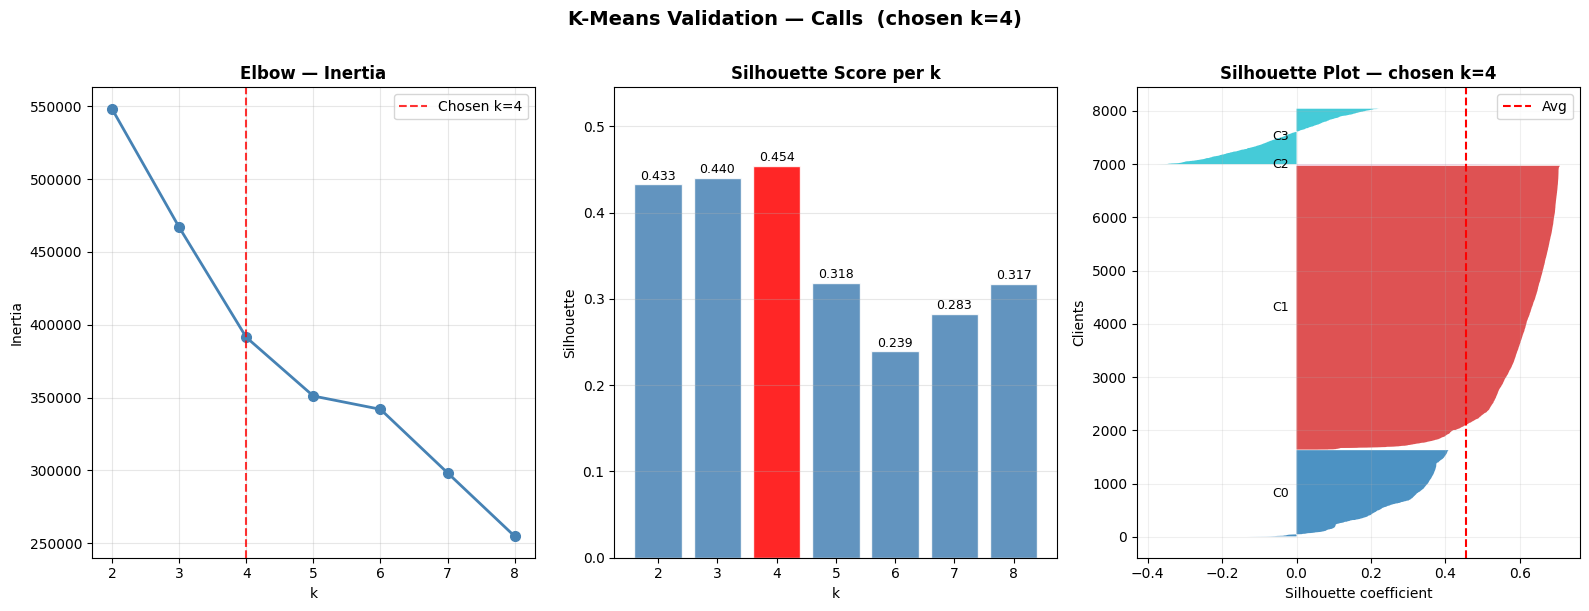


════════════════════════════════════════════════════════════
CLUSTER PROFILES (raw means)
════════════════════════════════════════════════════════════
         recency  customer_age  total_purchases  total_spent  avg_order_value  unique_products  purchase_velocity  avg_gap_days
cluster                                                                                                                        
0         228.05        544.16             5.47        40.29             8.82             1.20               3.72        104.05
1         481.51        551.80             1.24         4.83             3.92             1.00              29.34          2.12
2         482.13        560.29             1.99         9.01             4.45             1.34              30.00          9.66
3         170.81        571.10            56.70      1068.25            26.73             1.08               6.14          9.69


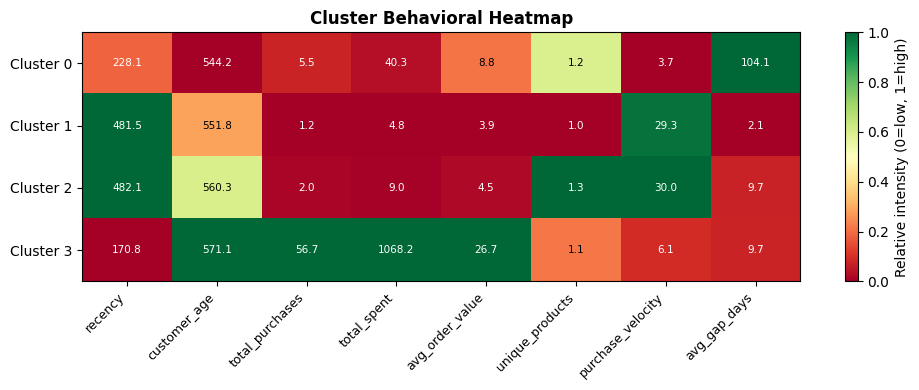


Cluster sizes:
 cluster  count  pct
       0   7291 12.7
       1  38416 67.2
       2  11410 19.9
       3     80  0.1


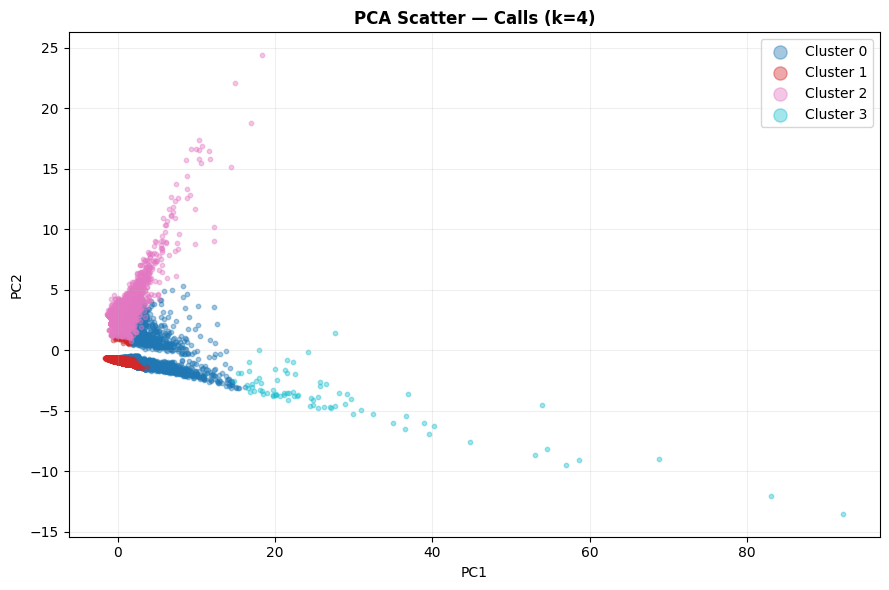

In [13]:
calls_clients_labeled,   calls_profiles,   calls_km   = run_group(calls_clients,   'Calls')


═════════════════════════════════════════════════════════════════
  GROUP: Data eSIM
═════════════════════════════════════════════════════════════════
  PCA: 8 components → 90.5% variance explained

  k |      Inertia | Silhouette | Avg cluster sizes
─────────────────────────────────────────────────────────────────
  2 |      788,199 |     0.5678 | C0:6,673  C1:66,452
  3 |      664,039 |     0.5678 | C0:6,673  C1:66,449  C2:3
  4 |      511,584 |     0.5106 | C0:6,505  C1:51,523  C2:3  C3:15,094
  5 |      388,821 |     0.5100 | C0:6,527  C1:51,214  C2:3  C3:14,479  C4:902
  6 |      346,170 |     0.3423 | C0:6,525  C1:32,184  C2:3  C3:13,682  C4:902  C5:19,829
  7 |      328,632 |     0.3360 | C0:6,513  C1:30,807  C2:3  C3:8,268  C4:901  C5:18,231  C6:8,402
  8 |      262,196 |     0.3718 | C0:5,836  C1:32,030  C2:2,310  C3:11,316  C4:3  C5:1,221  C6:19,881  C7:528

 Recommended k = 2  (global best silhouette = k=2)


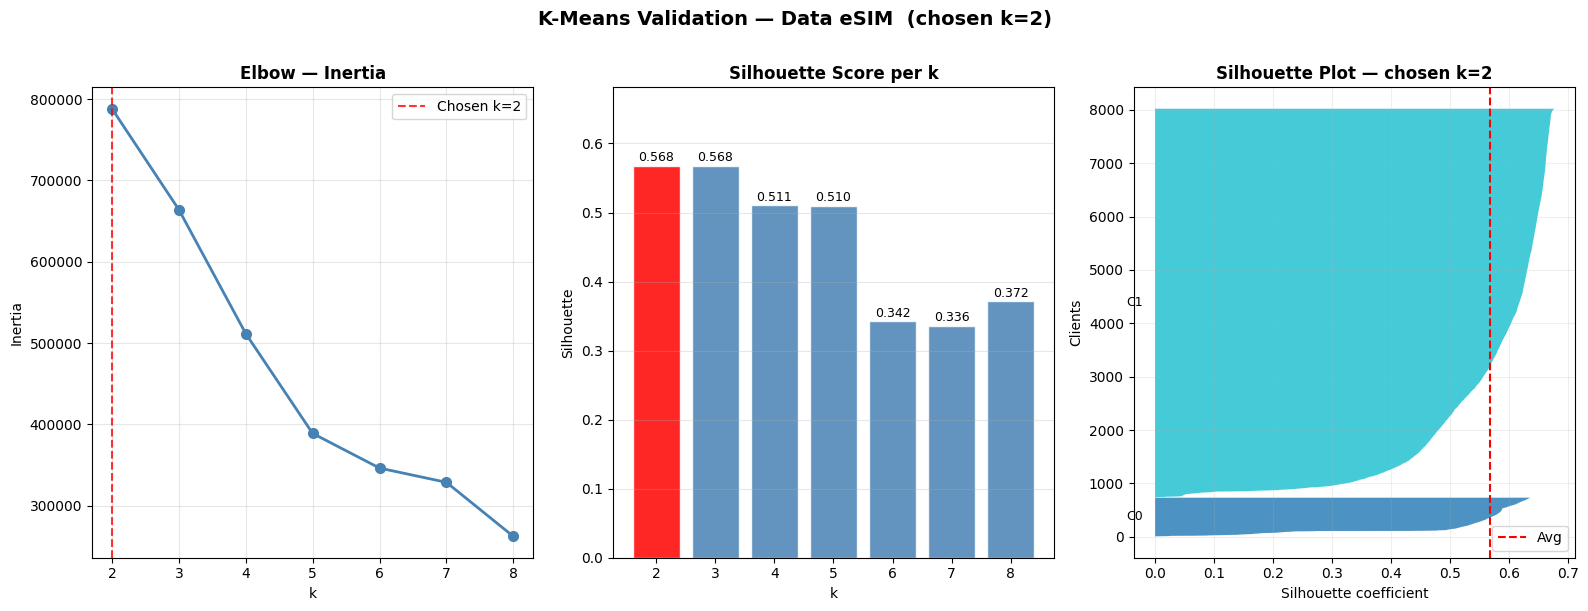


════════════════════════════════════════════════════════════
CLUSTER PROFILES (raw means)
════════════════════════════════════════════════════════════
         recency  customer_age  total_purchases  total_spent  avg_order_value  unique_products  purchase_velocity  avg_gap_days
cluster                                                                                                                        
0         530.73        564.44             1.30        16.83            13.17             1.13              28.00         10.54
1         395.10        508.52             1.84        16.42             8.69             1.01              22.98         27.49


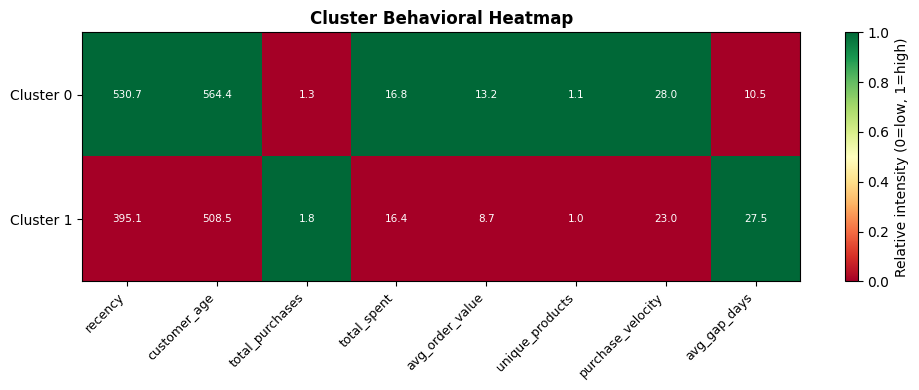


Cluster sizes:
 cluster  count  pct
       0   6673  9.1
       1  66452 90.9


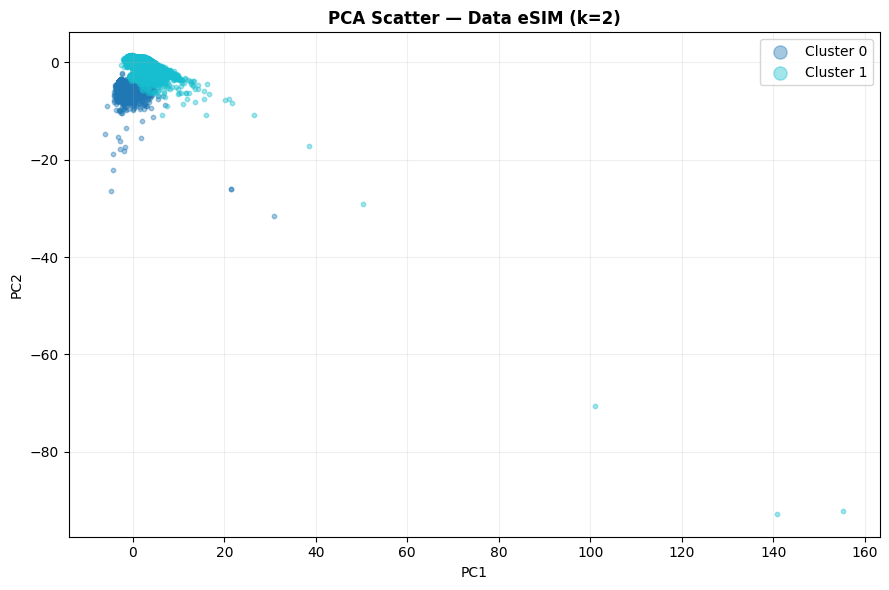

In [14]:
esim_clients_labeled,    esim_profiles,    esim_km    = run_group(esim_clients,    'Data eSIM')


═════════════════════════════════════════════════════════════════
  GROUP: Virtual Number
═════════════════════════════════════════════════════════════════
  PCA: 9 components → 92.0% variance explained

  k |      Inertia | Silhouette | Avg cluster sizes
─────────────────────────────────────────────────────────────────
  2 |    2,440,740 |     0.5173 | C0:13,956  C1:190,865
  3 |    2,013,582 |     0.4220 | C0:31,465  C1:144,276  C2:29,080
  4 |    1,785,928 |     0.4221 | C0:31,386  C1:144,238  C2:29,076  C3:121
  5 |    1,609,686 |     0.3548 | C0:12,253  C1:45,041  C2:3,629  C3:119  C4:143,779
  6 |    1,501,865 |     0.2457 | C0:12,488  C1:9,985  C2:11,686  C3:121  C4:81,471  C5:89,070
  7 |    1,294,028 |     0.2907 | C0:10,102  C1:7,693  C2:9,053  C3:121  C4:71,401  C5:77,326  C6:29,125
  8 |    1,320,322 |     0.3057 | C0:9,915  C1:72,655  C2:65,704  C3:21,238  C4:13,302  C5:1,720  C6:19,505  C7:782

 Recommended k = 2  (global best silhouette = k=2)


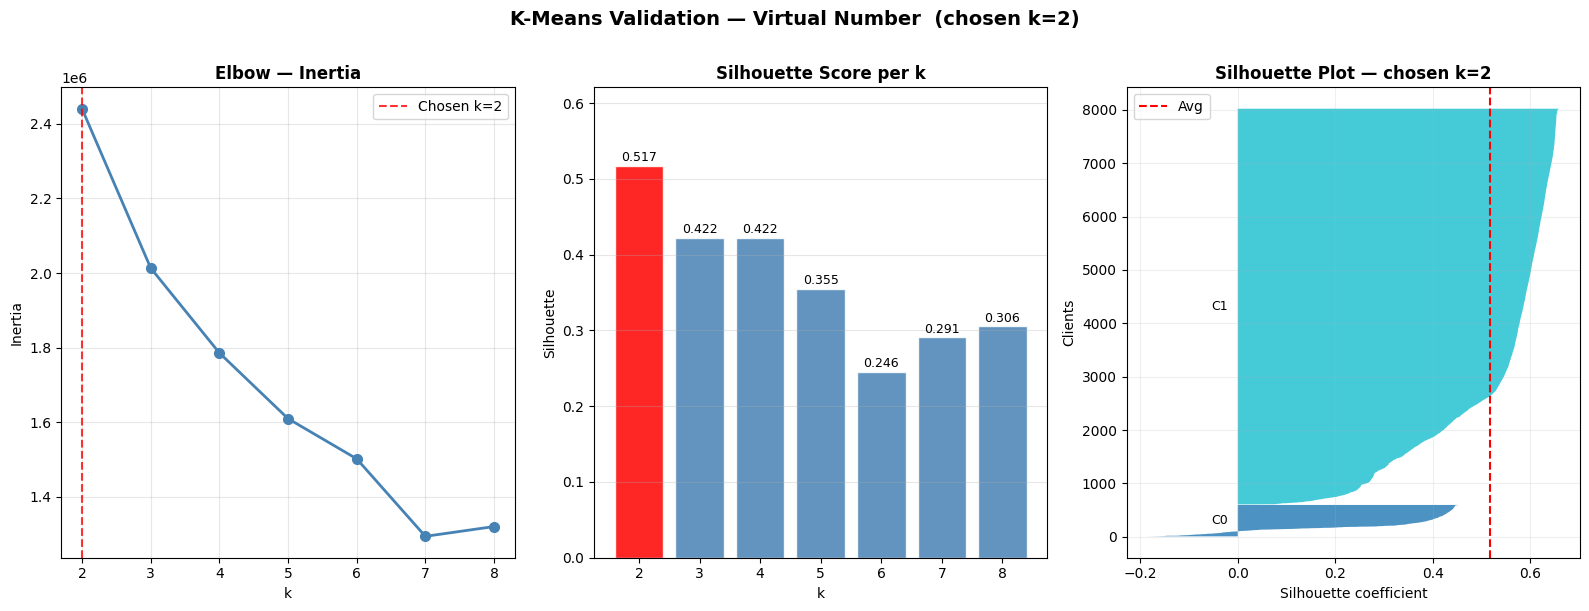


════════════════════════════════════════════════════════════
CLUSTER PROFILES (raw means)
════════════════════════════════════════════════════════════
         recency  customer_age  total_purchases  total_spent  avg_order_value  unique_products  purchase_velocity  avg_gap_days
cluster                                                                                                                        
0         415.38        559.12             5.16        25.30             4.89             1.75              24.19         25.73
1         485.36        564.78             2.16        12.03             6.34             1.00              21.54         23.15


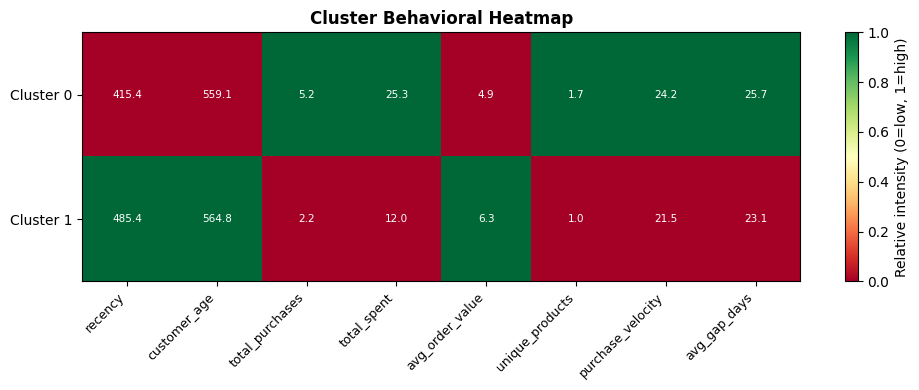


Cluster sizes:
 cluster  count  pct
       0  46239 22.6
       1 158582 77.4


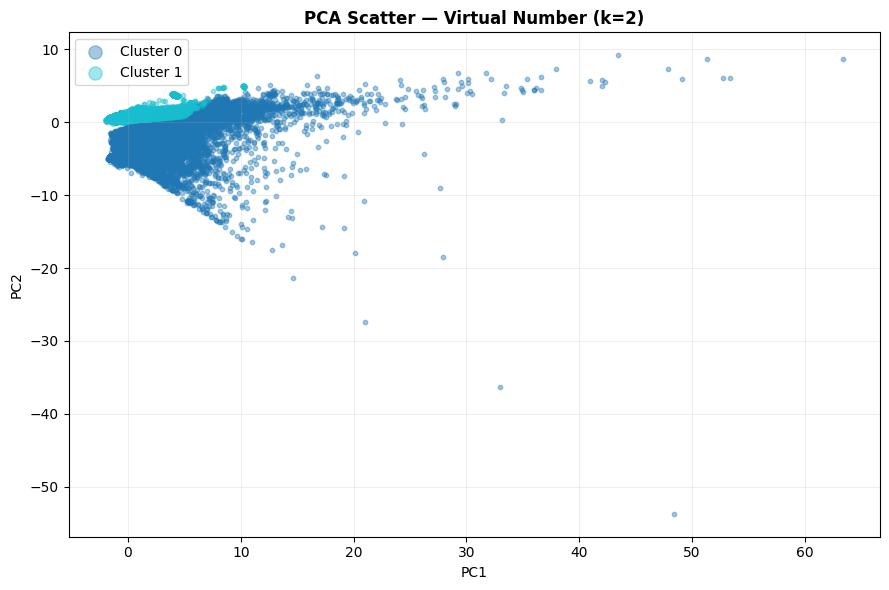

In [15]:
virtual_clients_labeled, virtual_profiles, virtual_km = run_group(virtual_clients, 'Virtual Number')